In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra, StatsBase;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
write_map_write_h("wannier-0.289", [12, 12, 1], spin=Val('d'))

In [4]:
HePhWannier, cellMapEph = write_eph_matrix_elements("wannier-0.289", 53*3, [1, 1, 1], Val('u'))
force_matrix, phonon_cell_map = phonon_force_matrix("Na-0.289");

Number of phonon modes is: 159
If this is incorrect, something went wrong somewhere at some point.


In [6]:
argmax(abs.(eph_matrix_elements(HePhWannier, cellMapEph, force_matrix, phonon_cell_map, [0, 0, 0], [0.2, 0.3, 0])))

80

In [7]:
Hwannierup, cellmapup = hwannier("wannier-0.289Up.txt", "wannier-0.289Up.map.txt"), np.loadtxt("wannier-0.289Up.map.txt");


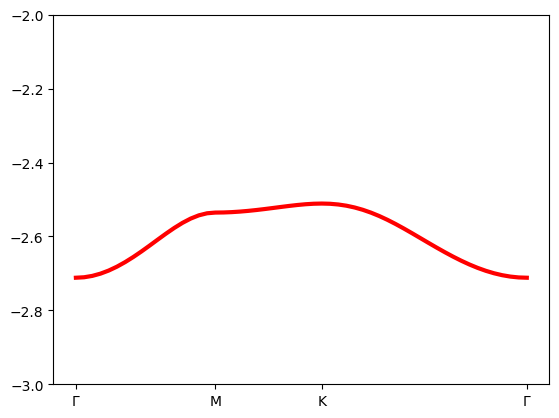

(PyObject[PyObject <matplotlib.axis.XTick object at 0x7f1dfb7c1d30>, PyObject <matplotlib.axis.XTick object at 0x7f1dfb7c1d00>, PyObject <matplotlib.axis.XTick object at 0x7f1da6256850>, PyObject <matplotlib.axis.XTick object at 0x7f1dfb7f3a30>], PyObject[PyObject Text(0, 0, 'Γ'), PyObject Text(17, 0, 'M'), PyObject Text(30, 0, 'K'), PyObject Text(55, 0, 'Γ')])

In [8]:
plotwannierbands(Hwannierup, cellmapup, 1, linewidth=3, color="red")
ylim(-3, -2)
label_plots()

In [9]:
lattice_vectors = loadlattice("wannier.out")
v1, v2, v3 = lattice_vectors

3-element Vector{Vector{Float64}}:
 [8.7558684774, -2.1665141392400002, 0.0]
 [-6.2541842099, -6.499563584800001, 0.0]
 [0.0, 0.0, 21.16708]

In [10]:
q = unnormalize_kvector(lattice_vectors, [0.5, 0, 0])

3-element Vector{Float64}:
  0.28979905371452486
 -0.2788582098071919
  0.0

In [11]:
gvectors = loadreciprocallattice("wannier.out")

3-element Vector{Vector{Float64}}:
 [0.5795981306821725, -0.5577169831644232, -0.0]
 [-0.19319811707613896, -0.7808030205394415, 0.0]
 [-0.0, 0.0, 0.2968382979607957]

In [78]:
gvectors[1]/2

3-element Vector{Float64}:
  0.28979906534108624
 -0.2788584915822116
 -0.0

In [79]:
cross(v1, v2)[3]/13/1.45/1.45/3*2/sqrt(3)

-0.9922151713000783

In [22]:
eph_lifetimes = [JJDFTX.migdal_approximation(Hwannierup, cellmapup, HePhWannier, cellMapEph, force_matrix, phonon_cell_map, 
lattice_vectors, unnormalize_kvector(lattice_vectors, [1, 0, 0]*(i-1)/10), -2.6,  mesh=20, histogram_width=30) for i in 1:11] 

11-element Vector{Float64}:
 0.06875909801001565
 0.038669176098643114
 0.005742098244571311
 0.000976602777644615
 0.01017808059647816
 0.016111549836576127
 0.010178080596478142
 0.0009766027776446208
 0.005742098244571292
 0.03866917609864312
 0.06875909801001558

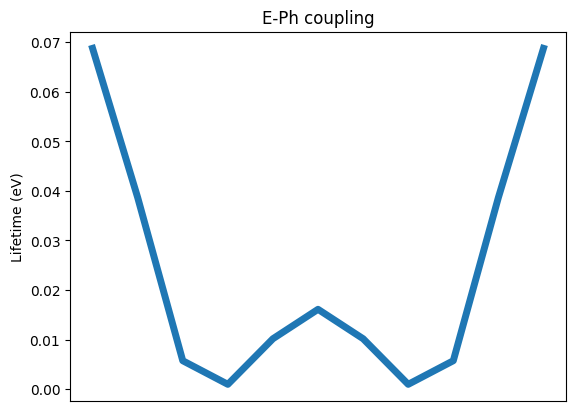

PyObject Text(24.000000000000007, 0.5, 'Lifetime (eV)')

In [24]:
plot(smooth(eph_lifetimes, win_len=3), linewidth=5)
xticks(Float64[])
title("E-Ph coupling")
ylabel("Lifetime (eV)")

In [96]:
sorderloss = second_order_damping(Hwannierup, cellmapup, HePhWannier, cellMapEph, force_matrix, phonon_cell_map, 
    lattice_vectors, q, -2.6; histogram_width=10, mesh=5, energy_range=3) 


1
1
1
1
1
1
1


30-element Vector{Float64}:
 0.0
 2.1580420385554615e15
 2.7254875478892955e15
 7.908412107864186e14
 5.335536526020581e13
 1.245682003372464e12
 3.195621485803578e9
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

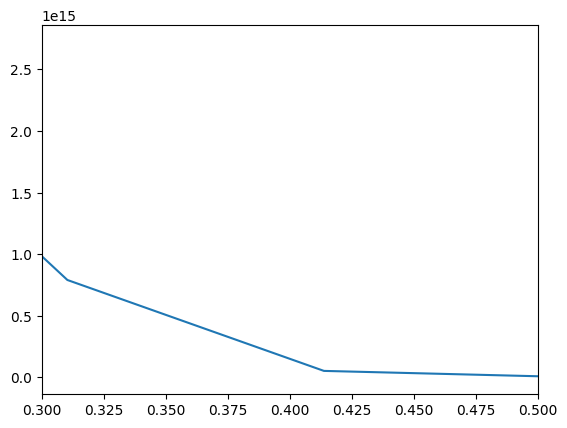

(0.3, 0.5)

In [103]:
plot(range(0, 3, length=30), sorderloss)
xlim(0.3, 0.5)
#ylim(0,1e15)

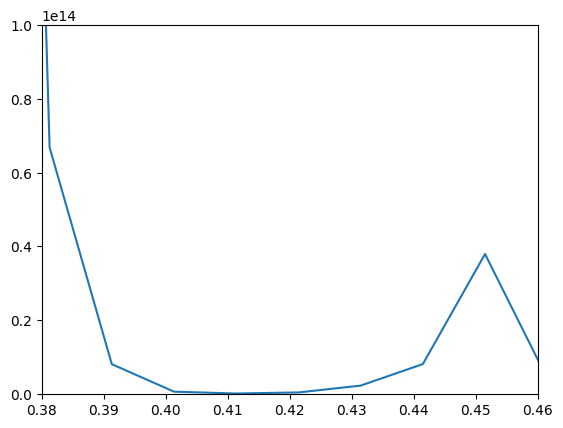

(0.0, 1.0e14)

In [90]:
plot(range(0, 3, length=300), sorderloss)
xlim(0.38, 0.46)
ylim(0,10e13)

In [25]:
pwd()

"/home/gridsan/aligho/Plasmons/Plasmons_Paper/Moire_Figs/Moire13_with_Alkali/Sodium/plasmon_losses"